# AdD 2B2026 - Actividad 2

CONSIGNA

Seleccionar uno de los datasets disponibles [aquí](https://docs.google.com/spreadsheets/d/1IiOaTJqDJyFUnVUkY78IZSO2rRq3C2LR0Cea-ZyX6HM/edit?gid=0#gid=0). Pueden elegir el propio o uno propuesto por un/a compañero/a.

Realizar un EDA básico del dataset seleccionado:

- estadística descriptiva
- tipos de variables
- relación entre variables
- incluir al menos 3 gráficos

Guardarlo en un repositorio de acceso público o en una notebook de Google Colab. Lo importante es que el código esté ejecutado (que muestre la salida).

---

# Cargando el Dataset

In [16]:
# Cargamos el dataset de https://www.kaggle.com/datasets/nalisha/smartphone-usage-and-addiction-analysis-dataset
import pandas as pd
from pandas import DataFrame
import os
import kagglehub

path = kagglehub.dataset_download("nalisha/smartphone-usage-and-addiction-analysis-dataset")
full_csv_path: str = os.path.join(path, os.listdir(path)[0])
df: DataFrame = pd.read_csv(full_csv_path)
df.head(5)

100%|██████████| 178k/178k [00:00<00:00, 11.4MB/s]

Extracting files...


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [ ]:
print(f"Dataframe shape: {df.shape}")
print(f"\nDataframe columns: ")
display(list(df.columns))

Dataframe shape: (7500, 16)

Dataframe columns: 


['transaction_id',
 'user_id',
 'age',
 'gender',
 'daily_screen_time_hours',
 'social_media_hours',
 'gaming_hours',
 'work_study_hours',
 'sleep_hours',
 'notifications_per_day',
 'app_opens_per_day',
 'weekend_screen_time',
 'stress_level',
 'academic_work_impact',
 'addiction_level',
 'addicted_label']

El dataset elegido es [Smartphone Usage & Addiction Analysis Dataset](https://www.kaggle.com/datasets/nalisha/smartphone-usage-and-addiction-analysis-dataset), el cual consiste de 7500 registros que capturan el comportamiento de smartphones y patrones de adiccion.


Consultamos el significado de cada feature (columnas) directamente desde la documentacion del dataset

| Column Name | Description | Descripción |
|---|---|---|
| `User_ID` | Unique identifier for each user | Identificador único para cada usuario |
| `Age` | Age of the user | Edad del usuario |
| `Gender` | Gender of the user | Género del usuario |
| `Daily_Screen_Time` | Average daily screen time (hours) | Tiempo promedio diario frente a la pantalla (horas) |
| `App_Usage_Time` | Time spent on mobile applications | Tiempo dedicado a aplicaciones móviles |
| `Social_Media_Usage` | Time spent on social media | Tiempo dedicado a redes sociales |
| `Gaming_Time` | Time spent on mobile games | Tiempo dedicado a juegos móviles |
| `Work_Usage` | Time spent on productive/work-related apps | Tiempo dedicado a apps productivas o de trabajo |
| `Addiction_Level` | Calculated addiction score or category | Puntuación o categoría de adicción calculada |
| `Sleep_Hours` | Average sleep duration | Duración promedio del sueño |
| `Location` | User location (if included) | Ubicación del usuario (si está incluida) |

Las ultimas columnas no estan descriptas pero las inferimos segun el contexto

| Column Name | Description | Descripción |
|---|---|---|
| `transaction_id` | Unique identifier for each transaction record | Identificador único para cada registro de transacción |
| `notifications_per_day` | Number of notifications received per day | Cantidad de notificaciones recibidas por día |
| `app_opens_per_day` | Number of times apps are opened per day | Cantidad de veces que se abren aplicaciones por día |
| `weekend_screen_time` | Screen time during weekends (hours) | Tiempo frente a la pantalla durante los fines de semana (horas) |
| `stress_level` | Measured or self-reported stress level of the user | Nivel de estrés medido o autoreportado por el usuario |
| `academic_work_impact` | Impact of device usage on academic or work performance | Impacto del uso del dispositivo en el rendimiento académico o laboral |
| `addicted_label` | Binary label indicating addiction status | Etiqueta binaria que indica el estado de adicción |

Omitiremos `User_ID` y `transaction_id` en el analisis

# Analisis EDA

Empezaremos explorando estadística descriptiva y los tipos de variables que el dataset tiene

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

Podemos observar que tenemos las siguientes variables:

**Categóricas**

| **Subtipo** | **Variables** |
|---|---|
| Nominales | `gender`, `academic_work_impact`, `addicted_label` |
| Ordinales | `stress_level`, `addiction_level` |

**Cuantitativas**

| **Subtipo** | **Variables** |
|---|---|
| Discretas | `age`, `notifications_per_day`, `app_opens_per_day` |
| Continuas | `daily_screen_time_hours`, `social_media_hours`, `gaming_hours`, `work_study_hours`, `sleep_hours`, `weekend_screen_time` |

Analizamos las metricas descriptivas para las variables cuantitativas

In [ ]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


Evaluamos las relaciones entre variables usando una matriz de correlación utilizando la correlacion de Pearson, Spearman & Kendall


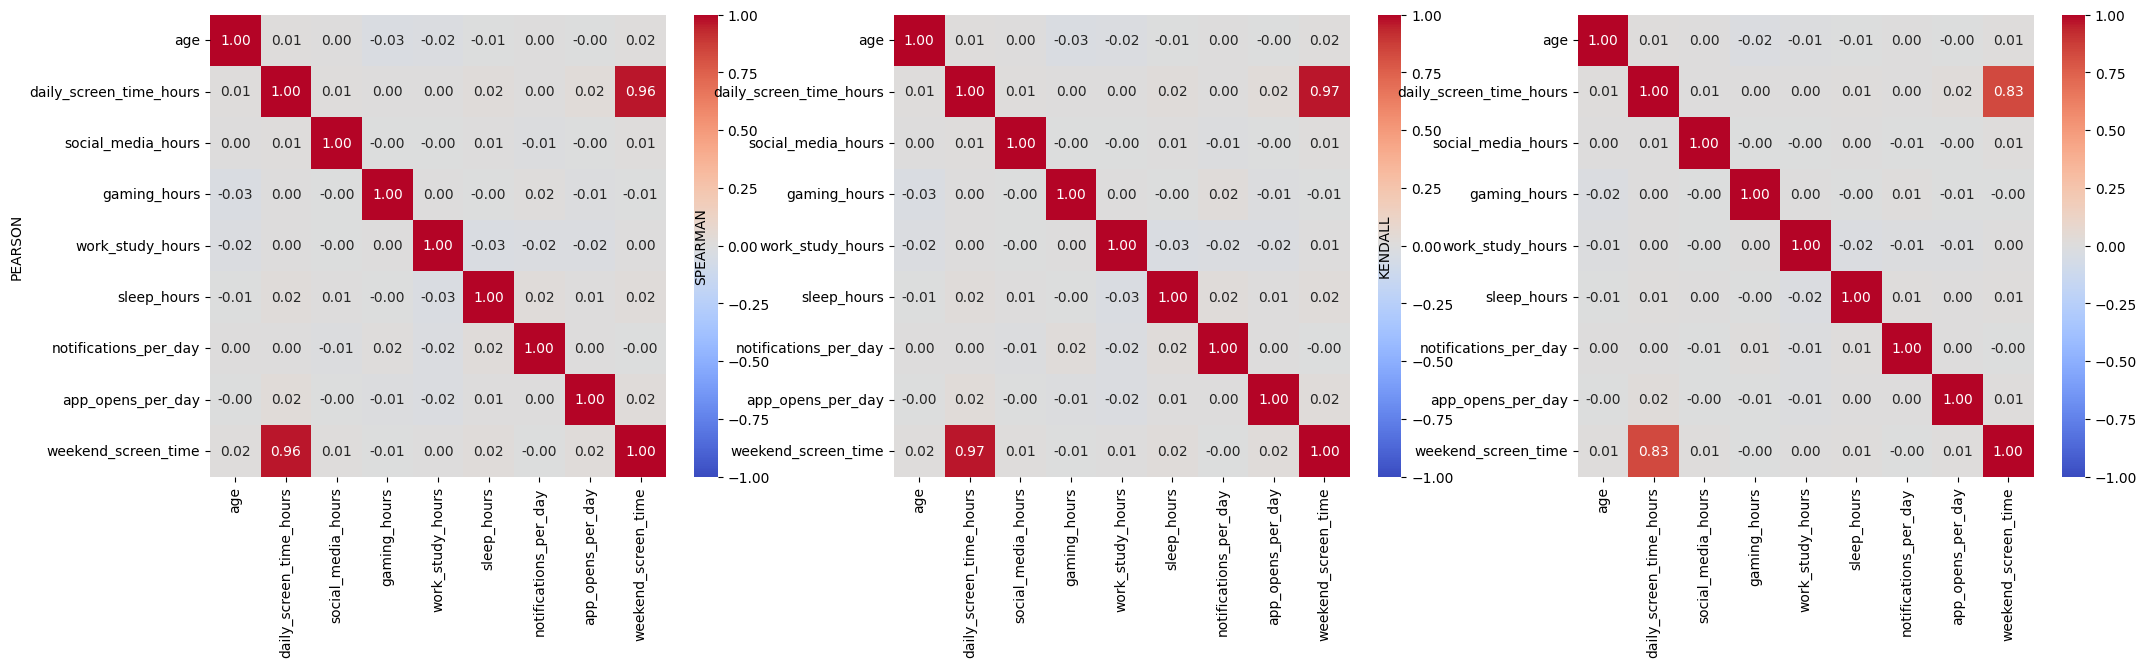

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_columns = ['age',
 'daily_screen_time_hours',
 'social_media_hours',
 'gaming_hours',
 'work_study_hours',
 'sleep_hours',
 'notifications_per_day',
 'app_opens_per_day',
 'weekend_screen_time']

plt.figure(figsize=(25,6))

plt.subplot(1, 3, 1)
sns.heatmap(
    df[numerical_columns].corr(numeric_only=False),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1)
plt.ylabel('PEARSON')

plt.subplot(1, 3, 2)
sns.heatmap(
    df[numerical_columns].corr(method='spearman', numeric_only=False),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,)
plt.ylabel('SPEARMAN')

plt.subplot(1, 3, 3)
sns.heatmap(
    df[numerical_columns].corr(method='kendall', numeric_only=False),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,)
plt.ylabel('KENDALL')

plt.show()

Notamos que entre `daily_screen_time_hours` y `weekend_screen_time` existe una correlacion muy fuerte.

Es una señal fuerte de que es una par de variables correlacionadas; sin embargo, amerita ver de cerca si no es que ambas features en realidad estan midiendo lo mismo (horas de uso en los dias sabado y domingo)

## Graficos

### Distribucion de edades
Evaluamos la distribucion de `age` de la muestra de los usuarios para averiguar

Moda: 31 años
Media: 26.5688 años
Mediana: 27.0 años


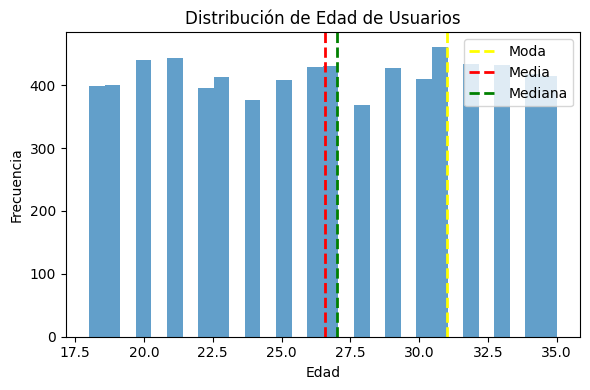

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(df['age'], bins=30, alpha=0.7)
ax.axvline(df['age'].mode()[0], color='yellow', ls='--', lw=2, label='Moda')
ax.axvline(df['age'].mean(), color='red', ls='--', lw=2, label='Media')
ax.axvline(df['age'].median(), color='green', ls='--', lw=2, label='Mediana')
ax.set_title('Distribución de Edad de Usuarios')
ax.set_xlabel('Edad')
ax.set_ylabel('Frecuencia')
ax.legend()

plt.tight_layout()


print(f"Moda: {df['age'].mode()[0]} años")
print(f"Media: {df['age'].mean()} años")
print(f"Mediana: {df['age'].median()} años")
plt.show()

Observamos que estamos trabajando con una muestra casi por completo mayor de edad. Con una edad media de 26.5 años

### Cuantiles de la cantidad de horas de uso por dia
Evaluamos los cuartiles de `daily_screen_time_hours` para tener una idea de la distribucion de la cantidad de horas

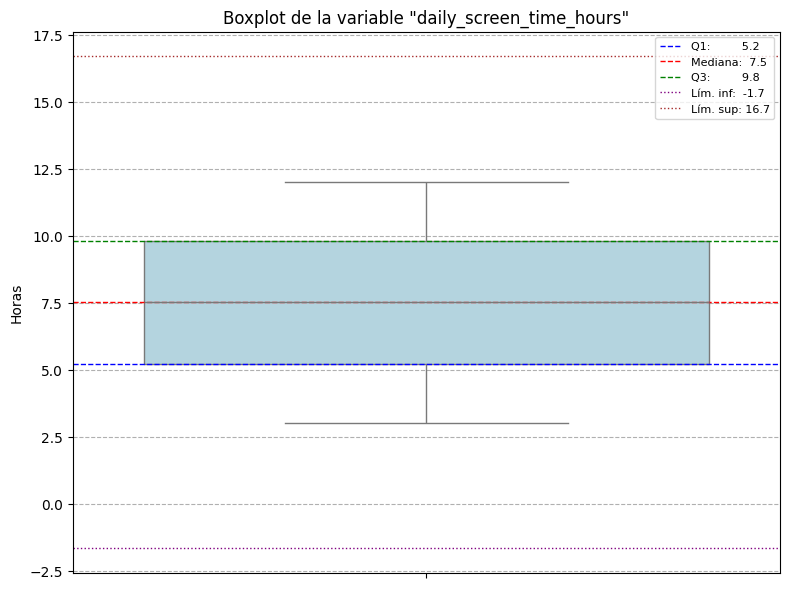

In [ ]:
dsth_Q1 = df['daily_screen_time_hours'].quantile(0.25)
dsth_Q2 = df['daily_screen_time_hours'].quantile(0.50)
dsth_Q3 = df['daily_screen_time_hours'].quantile(0.75)
dsth_IQR = dsth_Q3 - dsth_Q1

lower_limit = dsth_Q1 - 1.5 * dsth_IQR
upper_limit = dsth_Q3 + 1.5 * dsth_IQR


fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(data=df, y='daily_screen_time_hours', color="lightblue", ax=ax)
ax.axhline(dsth_Q1,      color='blue',   linestyle='--', linewidth=1, label=f'Q1:         {dsth_Q1:.1f}')
ax.axhline(dsth_Q2,      color='red',    linestyle='--', linewidth=1, label=f'Mediana:  {dsth_Q2:.1f}')
ax.axhline(dsth_Q3,      color='green',  linestyle='--', linewidth=1, label=f'Q3:         {dsth_Q3:.1f}')
ax.axhline(lower_limit, color='purple', linestyle=':',  linewidth=1, label=f'Lím. inf:  {lower_limit:.1f}')
ax.axhline(upper_limit, color='brown',  linestyle=':',  linewidth=1, label=f'Lím. sup: {upper_limit:.1f}')
ax.legend(fontsize=8)
ax.set_title('Boxplot de la variable "daily_screen_time_hours"')
ax.set_ylabel('Horas')
ax.grid(axis='y', ls='--')

plt.tight_layout()
plt.show()

Alarmantemente, vemos que la mediana es de 7.5 horas, lo que significa que la mitad de la muestra usa el smartphone mayor o igual a 7.5 horas por dia.

### Relación entre el tiempo diario de pantalla y el tiempo en redes sociales

Queremos saber, del total de tiempo de uso, cuanto tiempo se pasa en redes sociales?

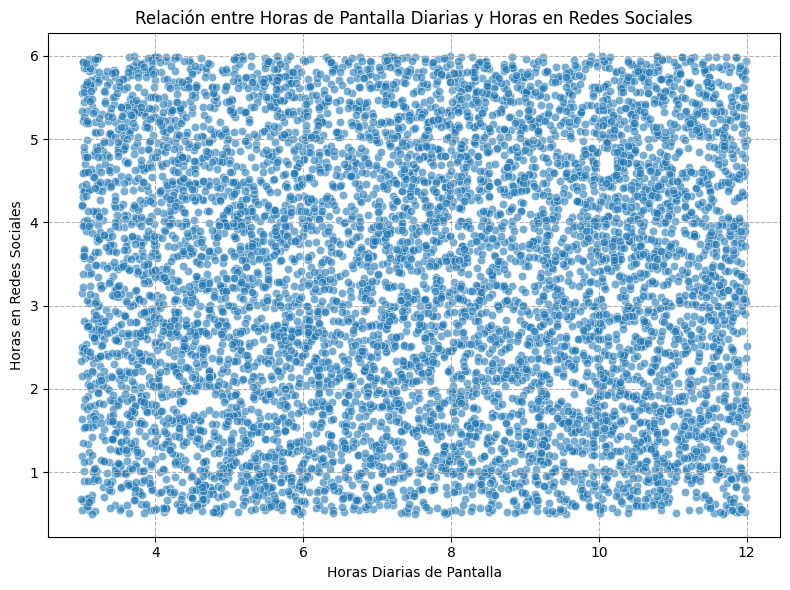

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='daily_screen_time_hours', y='social_media_hours', alpha=0.6)
plt.title('Relación entre Horas de Pantalla Diarias y Horas en Redes Sociales')
plt.xlabel('Horas Diarias de Pantalla')
plt.ylabel('Horas en Redes Sociales')
plt.grid(ls='--')
plt.tight_layout()
plt.show()

No vemos ningun patron evidente con respecto `daily_screen_time_hours` vs `social_media_hours`